# Transformer lab

A GPT, from empty file to trained model, one falsifiable step at a time.

Work top to bottom. Each exercise has a skeleton and a `check_*` call from
`checks.py` that will fail until your implementation is right — and fail with
a hint about *what kind* of wrong it is. `EXERCISES.md` is the guide;
`SOLUTIONS.md` is off-limits until you've genuinely tried.

Conventions used everywhere: tensors are `(B, T, C)` = (batch, time, channels).


In [1]:
import sys; print(sys.executable)

/Users/damianvandeheisteeg/Documents/python_projects/transformer_project/.venv/bin/python


In [6]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from minigpt.config import Config, ModelConfig
from minigpt.data import CharDataset
from minigpt.model import GPT
from minigpt.train import train, get_lr, estimate_loss

ds = CharDataset()
print(f"{ds.vocab_size} characters in vocabulary")

65 characters in vocabulary


## Check test functions

In [ ]:
def tiny_cfg(**kw: int) -> ModelConfig:
    base = dict(n_layer=2, n_head=2, n_embd=32, block_size=32, vocab_size=65)
    return ModelConfig(**{**base, **kw})

def test_causality_via_gradients():
    cfg = tiny_cfg()
    torch.manual_seed(0)
    m = GPT(tiny_cfg()).eval()
    x = torch.randn(1, 8, cfg.n_embd, requires_grad=True)
    attn = m.blocks[0].attn
    attn(x)[0, 3].sum().backward() # only run backward pass on 
    influence = x.grad[0].abs().sum(-1)
    return influence


test_causality_via_gradients()

from minigpt.data import 

tensor([0.0868, 0.0855, 0.0875, 0.0861, 0.0000, 0.0000, 0.0000, 0.0000])

## Trial run of repository

In [4]:
cfg = Config.from_yaml("configs/laptop.yaml")
cfg.train.max_steps = 500

model, ds, history = train(cfg)

step     0  train 4.2231  val 4.2235
step    50  train 3.3250  val 3.3405
step   100  train 2.7705  val 2.7965
step   150  train 2.6137  val 2.6107
step   200  train 2.5366  val 2.5129
step   250  train 2.5022  val 2.4944
step   300  train 2.4592  val 2.4489
step   350  train 2.4402  val 2.4392
step   400  train 2.4063  val 2.4151
step   450  train 2.4134  val 2.4144
step   499  train 2.4013  val 2.3900


Plot results

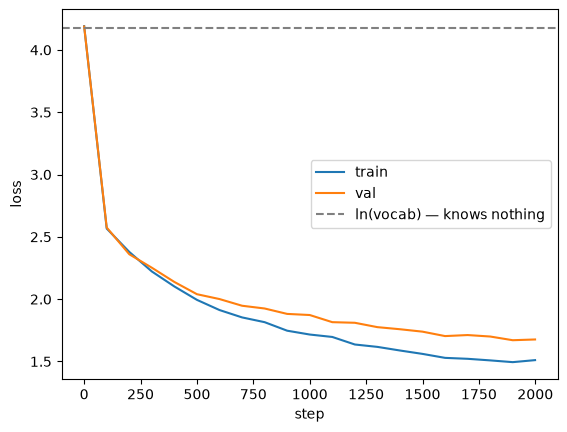

In [ ]:
plt.plot(history["step"], history["train"], label="train")
plt.plot(history["step"], history["val"], label="val")
plt.axhline(math.log(CharDataset().vocab_size), ls="--", c="gray", label="ln(vocab) — knows nothing")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend();

Generate samples

In [ ]:
idx = torch.tensor([ds.encode("\n")], dtype=torch.long)
print(ds.decode(model.generate(idx, 300, temperature=0.8)[0].tolist()))
# Extra: sweep temperature over [0.3, 0.8, 1.0, 1.5]. Temperature is exactly
# the Boltzmann beta^-1 -- watch the text freeze into repetition at low T and
# melt into noise at high T.


As such on this disfall beed thy stake his arm?

CAMILLO:
The last hath make her all bring as the friends
Of arth most consent themselves doth with the rabour.
Somethout from are the come lights me lags
And the dup of his time as, well.

Givong'd not is in the wordst matchmons, or the day.

Mosthoun
